### Imports

In [1]:
import random

import numpy as np
# Step 1: Install Required Libraries (uncomment if not installed)
# !pip install transformers torch scikit-learn pandas

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd
import seaborn as sns

In [2]:
# Currently set up to run on GPU on an M2 Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
# change these variables to either perform the original codebert fine-tunning or the hardening with our generated data
# if set to false, loads the previously trained model from disk and runs evaluation only
train_codebert = False
train_hardened = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

### Code from paper

In [4]:
# Step 2: Load and Preprocess the Dataset
# Load the synthetic dataset
df = pd.read_csv('data/SQL_injection_Dataset.csv')

df

,Query,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


In [5]:
class_counts = df['Label'].value_counts()
print(f"Original class distribution:\n{class_counts}")

Original class distribution:
Label
0    19537
1    11382
Name: count, dtype: int64


In [6]:
# Split the dataset into training and testing sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Query'].tolist(), df['Label'].tolist(), test_size=0.25, random_state=SEED
)

In [7]:
# Load CodeBERT tokenizer
tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')

# Tokenize the texts
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

In [8]:
# Step 3: Prepare Dataset for Training
class SQLInjectionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [9]:
train_dataset = SQLInjectionDataset(train_encodings, train_labels)
test_dataset = SQLInjectionDataset(test_encodings, test_labels)

In [10]:
# Step 4: Fine-Tune CodeBERT
model = RobertaForSequenceClassification.from_pretrained('microsoft/codebert-base', num_labels=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # number of training epochs
    per_device_train_batch_size=8,   # batch size for training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no",
    seed=SEED,
)

# Define a compute_metrics function for evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.from_numpy(logits), dim=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [30]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save_as=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malicious'],
                yticklabels=['Benign', 'Malicious'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    if save_as:
        plt.savefig(save_as, dpi=300, bbox_inches='tight')
    plt.show()
    return cm

In [13]:
# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset
    compute_metrics=compute_metrics      # evaluation metrics function
)

### Train codebert model

In [14]:
# Train the model
if train_codebert:
    trainer.train(resume_from_checkpoint=True)

### Save codebert model

In [15]:
# save the final model + tokenizer
if train_codebert:
    trainer.save_model("./fine_tuned_codebert_model")
    tokenizer.save_pretrained("./fine_tuned_codebert_model")

    print("Model and tokenizer saved to ./fine_tuned_codebert_model")

### Load codebert model

In [16]:
model = RobertaForSequenceClassification.from_pretrained("./fine_tuned_codebert_model")
tokenizer = RobertaTokenizer.from_pretrained("./fine_tuned_codebert_model")

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Evaluate codebert on original test set

Evaluating on device: mps
Evaluation results of codebert on original test set:
  accuracy: 0.9991
  f1: 0.9988
  precision: 0.9996
  recall: 0.9979


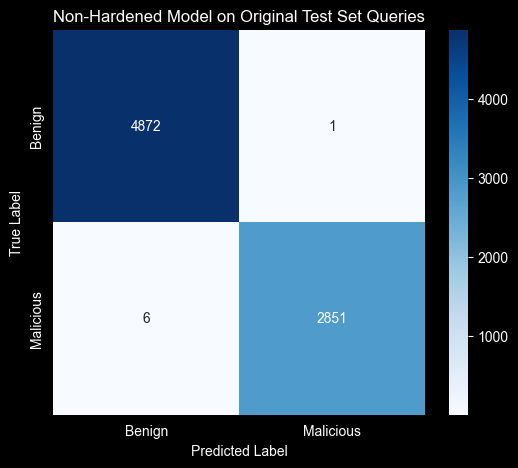

array([[4872,    1],
       [   6, 2851]])

In [17]:
print(f"Evaluating on device: {device}")

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        labels = batch["labels"].to(device)

        outputs = model(**inputs)
        logits = outputs.logits

        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
labels = np.concatenate(all_labels, axis=0)

eval_results = compute_metrics((logits, labels))

print("Evaluation results of codebert on original test set:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

plot_confusion_matrix(labels, np.argmax(logits, axis=-1),
                      title="Non-Hardened Model on Original Test Set Queries")

### Evaluating of non-hardened model on generated queries


Results of non-hardened model on unseen generated payloads
Total queries     : 1033
Detected malicious: 459/1033
Accuracy          : 0.4443
Precision         : 1.0000
Recall            : 0.4443
F1-score          : 0.6153


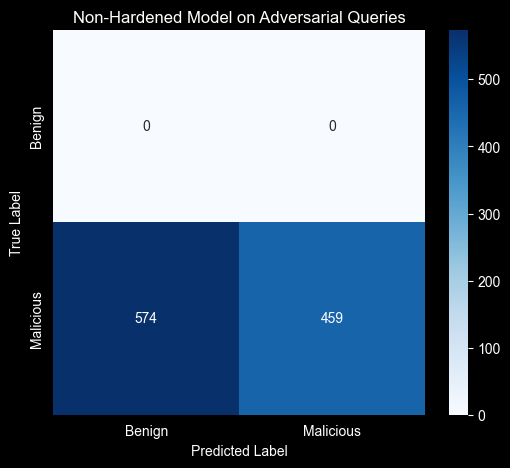

array([[  0,   0],
       [574, 459]])

In [18]:
new_csv_path = "data/adversarial_dataset.csv"
query_column = "payload"

df_new = pd.read_csv(new_csv_path)

queries = df_new[query_column].tolist()

# Device setup (M2 Mac)
model.to(device)
model.eval()

# Tokenize
new_encodings = tokenizer(
    queries,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)
new_encodings = {k: v.to(device) for k, v in new_encodings.items()}

with torch.no_grad():
    outputs = model(**new_encodings)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)

    predictions = torch.argmax(logits, dim=-1).cpu().numpy()
    confidence_malicious = probs[:, 1].cpu().numpy()

true_labels = [1] * len(predictions)

acc = accuracy_score(true_labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary', zero_division=0)

print("\nResults of non-hardened model on unseen generated payloads")
print(f"Total queries     : {len(queries)}")
print(f"Detected malicious: {predictions.sum()}/{len(predictions)}")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")

plot_confusion_matrix(true_labels, predictions,
                      title="Non-Hardened Model on Adversarial Queries")

### Model Hardening

In [19]:
df_new_samples = pd.read_csv("data/adversarial_dataset.csv")

new_queries = df_new_samples["payload"].tolist()
new_labels = df_new_samples["label"].tolist()

new_train_texts, new_test_texts, new_train_labels, new_test_labels = train_test_split(
    new_queries, new_labels, test_size=0.20, random_state=SEED
)

print(f"New queries split → {len(new_train_texts)} for training, {len(new_test_texts)} for testing")

New queries split → 826 for training, 207 for testing


In [20]:
combined_train_texts = train_texts + new_train_texts
combined_train_labels = train_labels + new_train_labels

print(f"New training set size: {len(combined_train_texts)} (original + {len(new_train_texts)} new malicious)")

New training set size: 24015 (original + 826 new malicious)


In [21]:
combined_test_texts = test_texts + new_test_texts
combined_test_labels = test_labels + new_test_labels

print(f"New training set size: {len(combined_test_texts)} (original + {len(new_test_texts)} new malicious)")

New training set size: 7937 (original + 207 new malicious)


In [22]:
combined_encodings = tokenizer(
    combined_train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

new_train_dataset = SQLInjectionDataset(combined_encodings, combined_train_labels)

In [23]:
combined_test_encodings = tokenizer(
    combined_test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

new_test_dataset = SQLInjectionDataset(combined_test_encodings, combined_test_labels)

In [24]:
model = RobertaForSequenceClassification.from_pretrained("./fine_tuned_codebert_model")

training_args = TrainingArguments(
    output_dir='./results_v2',
    num_train_epochs=2,                    # 1–2 epochs is plenty for fine-tuning
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,                    # lower LR = safer
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no",
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=new_train_dataset,
    eval_dataset=new_test_dataset,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Train and save hardened codebert

In [25]:
if train_hardened:
    trainer.train()

    trainer.save_model("./hardened_codebert_model")
    tokenizer.save_pretrained("./hardened_codebert_model")

    print("✅ Retraining finished! Model saved to ./hardened_codebert_model")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.000053,0.009556,0.998740,0.998368,0.998694,0.998042
2,0.000014,0.008172,0.999244,0.999020,0.999673,0.998368


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Retraining finished! Model saved to ./sql_injection_model_v2


### Load hardened codebert model

In [26]:
model_v2 = RobertaForSequenceClassification.from_pretrained("hardened_codebert_model")
tokenizer_v2 = RobertaTokenizer.from_pretrained("hardened_codebert_model")

model_v2.to(device)
model_v2.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Eval of hardened model on old test set

Evaluating on device: mps
Evaluation results of hardened model on old test set:
  accuracy: 0.9992
  f1: 0.9989
  precision: 0.9996
  recall: 0.9982


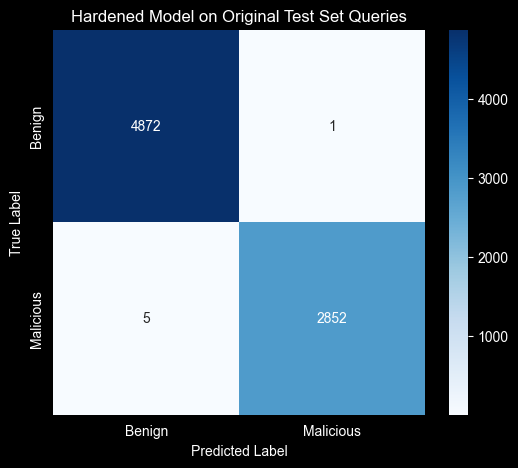


All predictions saved to → data/hardened-predictions_kaggle_test_set.csv


In [27]:
print(f"Evaluating on device: {device}")

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        labels = batch["labels"].to(device)

        outputs = model_v2(**inputs)
        logits = outputs.logits

        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
labels = np.concatenate(all_labels, axis=0)

eval_results = compute_metrics((logits, labels))

print("Evaluation results of hardened model on old test set:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

plot_confusion_matrix(labels, np.argmax(logits, axis=-1),
                      title="Hardened Model on Original Test Set Queries")

hardened_results = pd.DataFrame({
    'payload': test_texts,
    'label': labels,
    'hardened_pred_label': np.argmax(logits, axis=-1),
    'hardened_pred_score': torch.softmax(torch.from_numpy(logits), dim=-1)[:, 1].numpy()
})

output_csv = "data/hardened-predictions_kaggle_test_set.csv"
hardened_results.to_csv(output_csv, index=False)

print(f"\nAll predictions saved to → {output_csv}")

### Eval of hardened model on new test set (old test + 20% of generated queries)

Evaluating on device: mps
Evaluation results of hardened model on new test set (old test + 20% of generated queries):
  accuracy: 0.9992
  f1: 0.9990
  precision: 0.9997
  recall: 0.9984


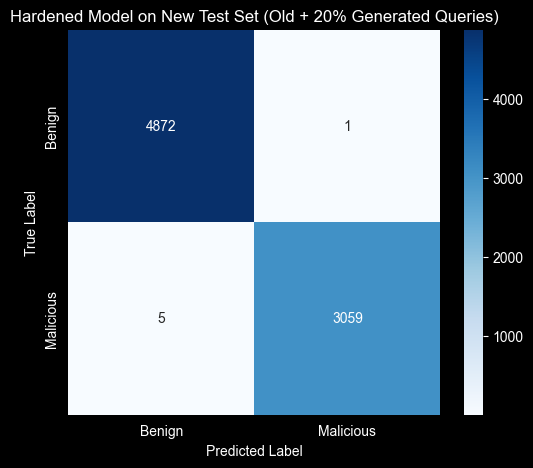

array([[4872,    1],
       [   5, 3059]])

In [28]:
print(f"Evaluating on device: {device}")

test_loader = DataLoader(
    new_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        labels = batch["labels"].to(device)

        outputs = model_v2(**inputs)
        logits = outputs.logits

        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
labels = np.concatenate(all_labels, axis=0)

eval_results = compute_metrics((logits, labels))

print("Evaluation results of hardened model on new test set (old test + 20% of generated queries):")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

plot_confusion_matrix(labels, np.argmax(logits, axis=-1),
                      title="Hardened Model on New Test Set (Old + 20% Generated Queries)")

### Eval of hardened model on unseen generated queries

Running inference on 207 queries using mps...

Results of hardened model on unseen generated payloads
Total queries     : 207
Detected malicious: 207/207
Accuracy          : 1.0000
Precision         : 1.0000
Recall            : 1.0000
F1-score          : 1.0000


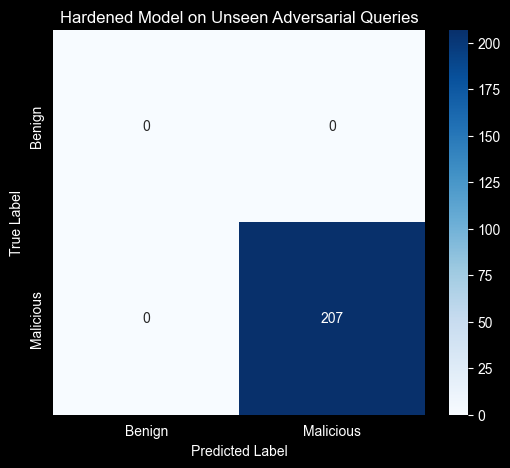


All predictions saved to → data/hardened-predictions_unseen_test_set.csv


In [31]:
queries = new_test_texts

print(f"Running inference on {len(queries)} queries using {device}...")

# Tokenize
new_encodings = tokenizer(
    queries,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)
new_encodings = {k: v.to(device) for k, v in new_encodings.items()}

with torch.no_grad():
    outputs = model_v2(**new_encodings)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)

    predictions = torch.argmax(logits, dim=-1).cpu().numpy()
    confidence_malicious = probs[:, 1].cpu().numpy()

true_labels = [1] * len(predictions)

acc = accuracy_score(true_labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary', zero_division=0)

print("\nResults of hardened model on unseen generated payloads")
print(f"Total queries     : {len(queries)}")
print(f"Detected malicious: {predictions.sum()}/{len(predictions)}")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")

plot_confusion_matrix(true_labels, predictions,
                      title="Hardened Model on Unseen Adversarial Queries")

hardened_results = pd.DataFrame({
    'payload': queries,
    'label': 1,
    'hardened_pred_label': predictions,
    'hardened_pred_score': confidence_malicious
})

output_csv = "data/hardened-predictions_unseen_test_set.csv"
hardened_results.to_csv(output_csv, index=False)

print(f"\nAll predictions saved to → {output_csv}")